# GAN MNIST DIGIT GENERATION

This project generates fake digits by training from the MNIST Dataset using Generative Adversial Networks (GAN).


## Import Statements

In [1]:

#Defines and trains neural networks
import torch
import torch.nn as nn
import torch.optim as optim

#Provides easy access to popular datasets (like MNIST), also transforms
#and normalises data
from torchvision import datasets, transforms

#Helps load data in mini batches
from torch.utils.data import DataLoader

#Used for plotting graphs
import matplotlib.pyplot as plt

#Used for plotting grids for display
import torchvision

#Numericals operations
import numpy as np

## Setting Hyperparameters

In [2]:
# Size of the input noise vector (random input to generator)
latent_dim = 100

# Number of samples per training batch
batch_size = 64

lr = 0.0002  #learning rate
epochs = 50  # number of iterations

## Flattened size of each image (MNIST is 28x28)
image_size = 28*28

#To switch to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data augmentation and loading the dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),             # Convert PIL image to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values from [0, 1] → [-1, 1]
])

#Loads the MNIST dataset
dataloader = DataLoader(
    datasets.MNIST(root='./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.58MB/s]


## Defining the Generator class

In [4]:
#Used to convert random noise into fake MNIST digits

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),    # Fully connected layer
            nn.LeakyReLU(0.2),             # Activation function
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, image_size),    # Output image (flattened)
            nn.Tanh()                      # Scale output to [-1, 1] range
        )

    def forward(self, z):
        return self.model(z)

## Defining the Discriminator Class

In [5]:
#This is a binary classifier that distinguishes between real and fake images.

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),         # Output: probability (real or fake)
            nn.Sigmoid()               # Output between 0 and 1
        )

    def forward(self, img):
        return self.model(img)


## Initializing Generator and Discriminator, Lossfunction and Optimizer

In [6]:
# Moves models to GPU if available.
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Uses Binary Cross Entropy to detrmine the function of Generator
criterion = nn.BCELoss()

# Adam is the optimizer of both networks
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)


## Training Model and Generating Digits

Epoch [1/50]  D_loss: 0.2835  G_loss: 3.6351


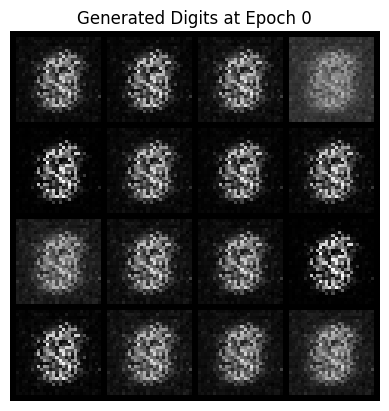

Epoch [2/50]  D_loss: 0.9569  G_loss: 1.7752
Epoch [3/50]  D_loss: 0.3775  G_loss: 3.3908
Epoch [4/50]  D_loss: 0.1762  G_loss: 3.8737
Epoch [5/50]  D_loss: 0.2662  G_loss: 3.0919
Epoch [6/50]  D_loss: 0.3833  G_loss: 3.3699
Epoch [7/50]  D_loss: 0.2700  G_loss: 3.5736
Epoch [8/50]  D_loss: 0.6384  G_loss: 1.7780
Epoch [9/50]  D_loss: 0.2418  G_loss: 3.1276
Epoch [10/50]  D_loss: 0.8935  G_loss: 1.3695
Epoch [11/50]  D_loss: 0.7076  G_loss: 1.7720


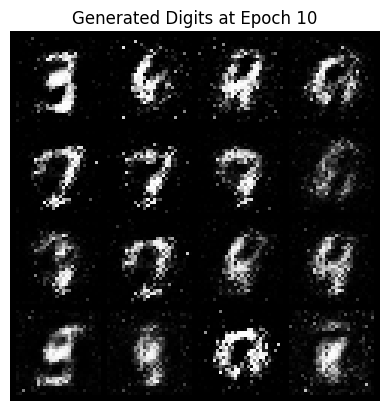

Epoch [12/50]  D_loss: 0.5411  G_loss: 2.0056
Epoch [13/50]  D_loss: 0.7637  G_loss: 1.5190
Epoch [14/50]  D_loss: 0.5627  G_loss: 2.4642
Epoch [15/50]  D_loss: 0.4871  G_loss: 2.1189
Epoch [16/50]  D_loss: 0.7520  G_loss: 1.7486
Epoch [17/50]  D_loss: 0.7600  G_loss: 2.4331
Epoch [18/50]  D_loss: 0.5402  G_loss: 2.0155
Epoch [19/50]  D_loss: 0.6782  G_loss: 1.3913
Epoch [20/50]  D_loss: 0.8148  G_loss: 2.2081
Epoch [21/50]  D_loss: 0.4914  G_loss: 2.2191


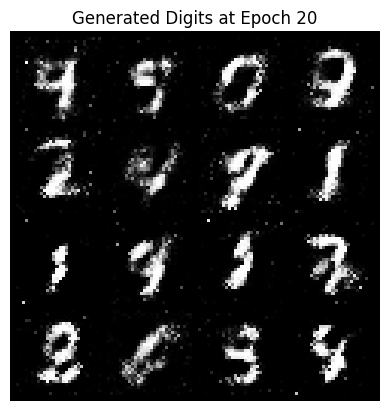

Epoch [22/50]  D_loss: 0.5727  G_loss: 1.8389
Epoch [23/50]  D_loss: 0.9071  G_loss: 1.8163
Epoch [24/50]  D_loss: 0.7058  G_loss: 1.9783
Epoch [25/50]  D_loss: 0.9492  G_loss: 1.6347
Epoch [26/50]  D_loss: 0.6302  G_loss: 2.5784
Epoch [27/50]  D_loss: 0.6105  G_loss: 2.1208
Epoch [28/50]  D_loss: 0.8808  G_loss: 2.4441
Epoch [29/50]  D_loss: 0.8284  G_loss: 1.5802
Epoch [30/50]  D_loss: 0.7705  G_loss: 1.5412
Epoch [31/50]  D_loss: 0.6179  G_loss: 2.2785


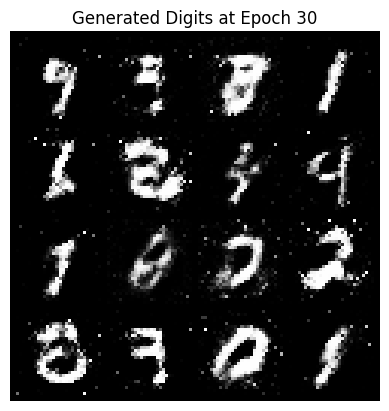

Epoch [32/50]  D_loss: 0.8675  G_loss: 1.9812
Epoch [33/50]  D_loss: 0.6069  G_loss: 1.8074
Epoch [34/50]  D_loss: 0.7910  G_loss: 1.8954
Epoch [35/50]  D_loss: 0.5786  G_loss: 2.1092
Epoch [36/50]  D_loss: 0.8684  G_loss: 1.8741
Epoch [37/50]  D_loss: 0.7677  G_loss: 1.4968
Epoch [38/50]  D_loss: 0.7787  G_loss: 1.3120
Epoch [39/50]  D_loss: 0.7654  G_loss: 1.6966
Epoch [40/50]  D_loss: 0.7787  G_loss: 1.4915
Epoch [41/50]  D_loss: 0.9240  G_loss: 1.4013


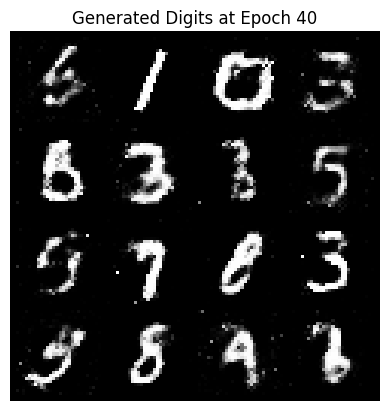

Epoch [42/50]  D_loss: 0.6897  G_loss: 1.3741
Epoch [43/50]  D_loss: 0.8572  G_loss: 1.9056
Epoch [44/50]  D_loss: 1.0371  G_loss: 1.4032
Epoch [45/50]  D_loss: 0.9659  G_loss: 1.9693
Epoch [46/50]  D_loss: 0.4506  G_loss: 2.2843
Epoch [47/50]  D_loss: 0.6280  G_loss: 2.3730
Epoch [48/50]  D_loss: 0.8006  G_loss: 2.5807
Epoch [49/50]  D_loss: 0.6955  G_loss: 1.9438
Epoch [50/50]  D_loss: 0.8831  G_loss: 1.9397


In [7]:
for epoch in range(epochs):

    #Sets up each mini batch with real image having label 1 and fake as 0
    for i, (imgs, _) in enumerate(dataloader):
        real_imgs = imgs.view(-1, image_size).to(device)
        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        # Train Generator
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        generated_imgs = generator(z)
        g_loss = criterion(discriminator(generated_imgs), real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        # Train Discriminator
        real_loss = criterion(discriminator(real_imgs), real_labels)
        fake_loss = criterion(discriminator(generated_imgs.detach()), fake_labels)
        d_loss = real_loss + fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

    #Logs losses back to training
    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")

    # Randomly samples 16 fake digits every 10 epochs
    # and displays them in a 4x4 grid.
    if epoch % 10 == 0:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim).to(device)
            generated = generator(test_z).view(-1, 1, 28, 28)
            grid_img = np.transpose(torchvision.utils.make_grid(generated, nrow=4, normalize=True).cpu(), (1, 2, 0))
            plt.imshow(grid_img)
            plt.title(f'Generated Digits at Epoch {epoch}')
            plt.axis('off')
            plt.show()
